
[![Electronic Profile](https://img.shields.io/badge/Electronic%20Profile-engineer--e-181717?logo=github)](https://github.com/engineer-e/) 
[![Work Profile](https://img.shields.io/badge/Work%20Profile-engineer--work-181717?logo=github)](https://github.com/engineer-work/) 
[![Instagram](https://img.shields.io/badge/Instagram-gobalkrishnan.engineer-E4405F?logo=instagram&logoColor=white)](https://www.instagram.com/gobalkrishnan.engineer/)

# 6. Surface Normals and Multiple Objects 

## 6.8  An Interval Class

Good point. The C++ book is now replacing raw `t_min, t_max` with an **interval object**.

This is an important design improvement.

It changes:

Before:

```python
world.hit(ray, t_min, t_max, rec)
```

After:

```python
world.hit(ray, Interval(t_min, t_max), rec)
```

This makes the code cleaner because:

| Old way             | Problem             |
| ------------------- | ------------------- |
| `t_min`, `t_max`    | two loose variables |
| easy to mix order   | bugs                |
| repeated everywhere | messy               |

With interval:

| New way             | Benefit            |
| ------------------- | ------------------ |
| `Interval(min,max)` | one object         |
| easier to pass      | cleaner            |
| reusable utilities  | better abstraction |

---

# 1. What is an Interval mathematically?

An interval is:

$$
[a,b]
$$

meaning:

all real numbers between (a) and (b)

Example:

$$
[2,5]
$$

contains:

$$
2,3,4,5
$$

---

For ray tracing:

Ray equation:

$$
P(t)=O+tD
$$

where:

| Symbol | Meaning            |
| ------ | ------------------ |
| $O$    | origin             |
| $D$    | direction          |
| $t$    | distance along ray |

We only accept:

$$
t_{min} < t < t_{max}
$$

because:

* avoid self-intersection
* avoid backward hits
* limit search range

That is exactly what interval stores.

---

# 2. Python version of `interval.h`

Create:

```python
# util/interval.py

class Interval:

    def __init__(self, min_val=float("inf"), max_val=float("-inf")):
        """
        Default = empty interval
        """
        self.min = min_val
        self.max = max_val

    def size(self):
        """
        Length of interval
        Formula:
        size = max - min
        """
        return self.max - self.min

    def contains(self, x):
        """
        Inclusive:
        min <= x <= max
        """
        return self.min <= x <= self.max

    def surrounds(self, x):
        """
        Strict:
        min < x < max
        """
        return self.min < x < self.max


# Static intervals
Interval.empty = Interval(float("inf"), float("-inf"))
Interval.universe = Interval(float("-inf"), float("inf"))
```

---

# 3. Learning notes

| Method         | Formula             | Purpose         |
| -------------- | ------------------- | --------------- |
| `size()`       | $max-min$           | interval length |
| `contains(x)`  | $min \le x \le max$ | inclusive check |
| `surrounds(x)` | $min < x < max$     | strict check    |
| `empty`        | $[+\infty,-\infty]$ | no values       |
| `universe`     | $[-\infty,+\infty]$ | all values      |

---

# 4. Update Hittable base class

Before:

```python
class Hittable:
    def hit(self, r, t_min, t_max, rec):
        pass
```

After:

```python
class Hittable:
    def hit(self, r, ray_t, rec):
        pass
```

---

Meaning:

| Variable    | Meaning     |
| ----------- | ----------- |
| `ray_t.min` | lower bound |
| `ray_t.max` | upper bound |

---

# 5. Update `Sphere.hit()`

Before:

```python
if root < t_min or root > t_max:
```

After:

```python
if not ray_t.surrounds(root):
```

Full:

```python
from util.interval import Interval

class Sphere(Hittable):

    def hit(self, r, ray_t, rec):

        oc = self.center - r.origin()

        a = dot(r.direction(), r.direction())
        h = dot(r.direction(), oc)
        c = dot(oc, oc) - self.radius * self.radius

        discriminant = h*h - a*c

        if discriminant < 0:
            return False

        sqrtd = math.sqrt(discriminant)

        # nearest root
        root = (h - sqrtd) / a

        if not ray_t.surrounds(root):
            root = (h + sqrtd) / a

            if not ray_t.surrounds(root):
                return False

        rec.t = root
        rec.p = r.at(root)

        outward_normal = (rec.p - self.center) / self.radius
        rec.normal = outward_normal

        return True
```

---

# Root formula

From quadratic:

$$
at^2-2ht+c=0
$$

Solution:

$$
t=\frac{h\pm\sqrt{h^2-ac}}{a}
$$

---

| Part            | Meaning                   |
| --------------- | ------------------------- |
| $h$             | projected center distance |
| $a$             | ray direction squared     |
| $c$             | sphere relation           |
| $\sqrt{h^2-ac}$ | intersection offset       |

---

# Why check nearest root first?

We want:

$$
t_1=\frac{h-\sqrt{D}}{a}
$$

because:

$$
t_1 < t_2
$$

Nearest visible object.

---

# 6. Update `HittableList.hit()`

Before:

```python
obj.hit(r, t_min, closest_so_far, rec)
```

After:

```python
obj.hit(r, Interval(ray_t.min, closest_so_far), rec)
```

Code:

```python
from util.interval import Interval

class HittableList(Hittable):

    def hit(self, r, ray_t, rec):

        temp_rec = HitRecord()
        hit_anything = False
        closest_so_far = ray_t.max

        for obj in self.objects:

            if obj.hit(r, Interval(ray_t.min, closest_so_far), temp_rec):
                hit_anything = True
                closest_so_far = temp_rec.t
                rec.copy(temp_rec)

        return hit_anything
```

---

Why shrink interval?

Suppose:

Object A hit:

$$
t=5
$$

Object B hit:

$$
t=2
$$

Then new interval becomes:

$$
[min,2]
$$

Anything farther than 2 ignored.

This guarantees closest object.

---

# 7. Update your `ray_color()`

Before:

```python
if world.hit(r, 0.001, INFINITY, rec):
```

After:

```python
from util.interval import Interval

if world.hit(r, Interval(0.001, INFINITY), rec):
```

Full:

```python
def ray_color(r, world):

    rec = HitRecord()

    if world.hit(r, Interval(0.001, INFINITY), rec):
        return 0.5 * (rec.normal + Vec3(1,1,1))

    unit_dir = unit_vector(r.direction())

    t = 0.5 * (unit_dir.y + 1.0)

    white = Vec3(1,1,1)
    blue = Vec3(0.5,0.7,1.0)

    return white*(1-t) + blue*t
```

---

# Flow now

Old:

$$
world.hit(ray,t_{min},t_{max},rec)
$$

New:

$$
world.hit(ray,[t_{min},t_{max}],rec)
$$

Cleaner abstraction.

Pipeline:

```text
Ray
 ↓
Interval(valid t range)
 ↓
HittableList
 ↓
Sphere
 ↓
Find root inside interval
 ↓
Return closest hit
```

---

# Big purpose of interval

| Purpose            | Why                           |
| ------------------ | ----------------------------- |
| Encapsulation      | groups min/max                |
| Cleaner API        | fewer parameters              |
| Safer logic        | avoids ordering bugs          |
| Reusable           | clamp, shadow rays, BVH later |
| Better abstraction | easier scaling                |

This small class becomes very important later for:

* shadows
* reflections
* refractions
* BVH acceleration

So it looks small now, but it is foundational.


In [1]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

from util.ray import Ray
from util.vec3 import Vec3
from util.color import write_color
from util.vec3 import unit_vector
from util.vec3 import dot
from tqdm import tqdm
from util.hit_record import HitRecord
from util.hittable import Hittable
from util.sphere import Sphere
from util.hittable_list import HittableList
from util.interval import Interval

import math

In [2]:

# Constants
INFINITY = float("inf")
PI = math.pi

# Utility
def degrees_to_radians(deg):
    return deg * PI / 180.0

### Interval

In [3]:
# util/interval.py

class Interval:

    def __init__(self, min_val=float("inf"), max_val=float("-inf")):
        """
        Default = empty interval
        """
        self.min = min_val
        self.max = max_val

    def size(self):
        """
        Length of interval
        Formula:
        size = max - min
        """
        return self.max - self.min

    def contains(self, x):
        """
        Inclusive:
        min <= x <= max
        """
        return self.min <= x <= self.max

    def surrounds(self, x):
        """
        Strict:
        min < x < max
        """
        return self.min < x < self.max


# Static intervals
Interval.empty = Interval(float("inf"), float("-inf"))
Interval.universe = Interval(float("-inf"), float("inf"))

### Old Code - Ray Color

```python
def ray_color(r, world):

    rec = HitRecord()

    # -----------------------------
    # HIT CHECK (WORLD INTERSECTION)
    # -----------------------------
    if world.hit(r, 0.001, INFINITY, rec):

        # Convert normal (-1 to 1) → (0 to 1)
        return 0.5 * (rec.normal + Vec3(1, 1, 1))

    # -----------------------------
    # BACKGROUND GRADIENT
    # -----------------------------
    unit_dir = unit_vector(r.direction())

    t = 0.5 * (unit_dir.y + 1.0)

    white = Vec3(1, 1, 1)
    blue = Vec3(0.5, 0.7, 1.0)

    return white * (1 - t) + blue * t

```

### New Code - Ray Color

In [4]:
def ray_color(r, world):

    rec = HitRecord()

    # -----------------------------
    # HIT CHECK (WORLD INTERSECTION)
    # -----------------------------
    if world.hit(r,Interval(0.001, INFINITY), rec):

        # Convert normal (-1 to 1) → (0 to 1)
        return 0.5 * (rec.normal + Vec3(1, 1, 1))

    # -----------------------------
    # BACKGROUND GRADIENT
    # -----------------------------
    unit_dir = unit_vector(r.direction())

    t = 0.5 * (unit_dir.y + 1.0)

    white = Vec3(1, 1, 1)
    blue = Vec3(0.5, 0.7, 1.0)

    return white * (1 - t) + blue * t

### Old Code - Hittable

```python
from abc import ABC, abstractmethod

class Hittable(ABC):

    @abstractmethod
    def hit(self, ray, tmin, tmax, rec):
        pass
```

### Old Code - Hittable List

```python
from typing import List, Optional
from util.hit_record import HitRecord
from util.hittable import Hittable
# We assume these exist already:
# Ray, HitRecord, Hittable
class HittableList:
    def __init__(self, obj=None):
        self.objects = []
        if obj is not None:
            self.add(obj)

    def add(self, obj):
        self.objects.append(obj)

    def hit(self, ray, tmin, tmax, rec):

        temp = HitRecord()
        hit_any = False
        closest = tmax

        for obj in self.objects:

            if obj.hit(ray, tmin, closest, temp):
                hit_any = True
                closest = temp.t
                rec.copy(temp)

        return hit_any
```

### New Code - Hittable

In [5]:
from abc import ABC, abstractmethod

class Hittable(ABC):

    @abstractmethod
    def hit(self, ray, ray_t, rec):
        pass



### New Code - Hittable List


In [6]:
from typing import List, Optional
from util.hit_record import HitRecord
from util.hittable import Hittable
# We assume these exist already:
# Ray, HitRecord, Hittable
class HittableList:
    def __init__(self, obj=None):
        self.objects = []
        if obj is not None:
            self.add(obj)

    def add(self, obj):
        self.objects.append(obj)

    def hit(self, ray, ray_t, rec):

        temp_rec = HitRecord()
        hit_anything = False
        closest_so_far = ray_t.max

        for obj in self.objects:

            if obj.hit(ray, Interval(ray_t.min, closest_so_far), temp_rec):
                hit_anything = True
                closest_so_far = temp_rec.t
                rec.copy(temp_rec)

        return hit_anything

### Old Code - Sphere

```python
class Sphere(Hittable):

    def __init__(self, center, radius):
        self.center = center
        self.radius = max(0.0, radius)

    def hit(self, ray, tmin, tmax, rec):

        # -----------------------------
        # VECTOR FROM RAY ORIGIN TO SPHERE CENTER
        # -----------------------------
        oc = self.center - ray.origin()

        # -----------------------------
        # QUADRATIC COEFFICIENTS
        # -----------------------------
        a = ray.direction().length_squared()
        h = dot(ray.direction(), oc)
        c = dot(oc, oc) - self.radius * self.radius

        discriminant = h * h - a * c

        # No real roots → no hit
        if discriminant < 0:
            return False

        sqrtd = math.sqrt(discriminant)

        # -----------------------------
        # FIND NEAREST VALID ROOT
        # -----------------------------
        root = (h - sqrtd) / a

        if root < tmin or root > tmax:
            root = (h + sqrtd) / a
            if root < tmin or root > tmax:
                return False

        # -----------------------------
        # FILL HIT RECORD
        # -----------------------------
        rec.t = root
        rec.p = ray.at(rec.t)

        # outward normal (unit sphere direction)
        outward_normal = (rec.p - self.center) / self.radius

        rec.set_face_normal(ray, outward_normal)

        return True 
```

# New Code - Sphere

In [7]:
import math
from util.hittable import Hittable
from util.vec3 import dot

class Sphere(Hittable):

    
    def __init__(self, center, radius):
        self.center = center
        self.radius = max(0.0, radius)

    def hit(self, r, ray_t, rec):

        oc = self.center - r.origin()

        a = dot(r.direction(), r.direction())
        h = dot(r.direction(), oc)
        c = dot(oc, oc) - self.radius * self.radius

        discriminant = h*h - a*c

        if discriminant < 0:
            return False

        sqrtd = math.sqrt(discriminant)

        # nearest root
        root = (h - sqrtd) / a

        if not ray_t.surrounds(root):
            root = (h + sqrtd) / a

            if not ray_t.surrounds(root):
                return False

        rec.t = root
        rec.p = r.at(root)

        outward_normal = (rec.p - self.center) / self.radius
        rec.normal = outward_normal

        return True

### Final Render

In [8]:
def render():

    import math

    # -----------------------------
    # IMAGE CONFIGURATION
    # -----------------------------
    aspect_ratio = 16 / 9
    image_width = 1920
    image_height = int(image_width / aspect_ratio)

    # -----------------------------
    # SCENE SETUP
    # -----------------------------
    world = HittableList()

    world.add(Sphere(Vec3(0, 0, -1), 0.5))
    world.add(Sphere(Vec3(0, -100.5, -1), 100))

    # -----------------------------
    # CAMERA SETUP
    # -----------------------------
    viewport_height = 2.0
    viewport_width = viewport_height * (image_width / image_height)
    focal_length = 1.0

    camera_center = Vec3(0, 0, 0)

    viewport_u = Vec3(viewport_width, 0, 0)
    viewport_v = Vec3(0, -viewport_height, 0)

    pixel_delta_u = viewport_u / image_width
    pixel_delta_v = viewport_v / image_height

    viewport_upper_left = (
        camera_center
        - Vec3(0, 0, focal_length)
        - viewport_u / 2
        - viewport_v / 2
    )

    pixel00 = viewport_upper_left + 0.5 * (pixel_delta_u + pixel_delta_v)

    # -----------------------------
    # PPM HEADER (WRITE TO FILE)
    # -----------------------------
    with open("output.ppm", "w") as f:
        f.write(f"P3\n{image_width} {image_height}\n255\n")

        # -----------------------------
        # RENDER LOOP
        # -----------------------------
        for j in tqdm(range(image_height), desc="Rendering"):
            for i in range(image_width):

                pixel_center = (
                    pixel00
                    + pixel_delta_u * i
                    + pixel_delta_v * j
                )

                direction = pixel_center - camera_center
                r = Ray(camera_center, direction)

                # NOW uses HitRecord internally
                col = ray_color(r, world)

                ir = int(255.999 * col.x)
                ig = int(255.999 * col.y)
                ib = int(255.999 * col.z)

                f.write(f"{ir} {ig} {ib}\n")

    print("Done!")

render()

Rendering: 100%|██████████| 1080/1080 [00:26<00:00, 40.34it/s]

Done!


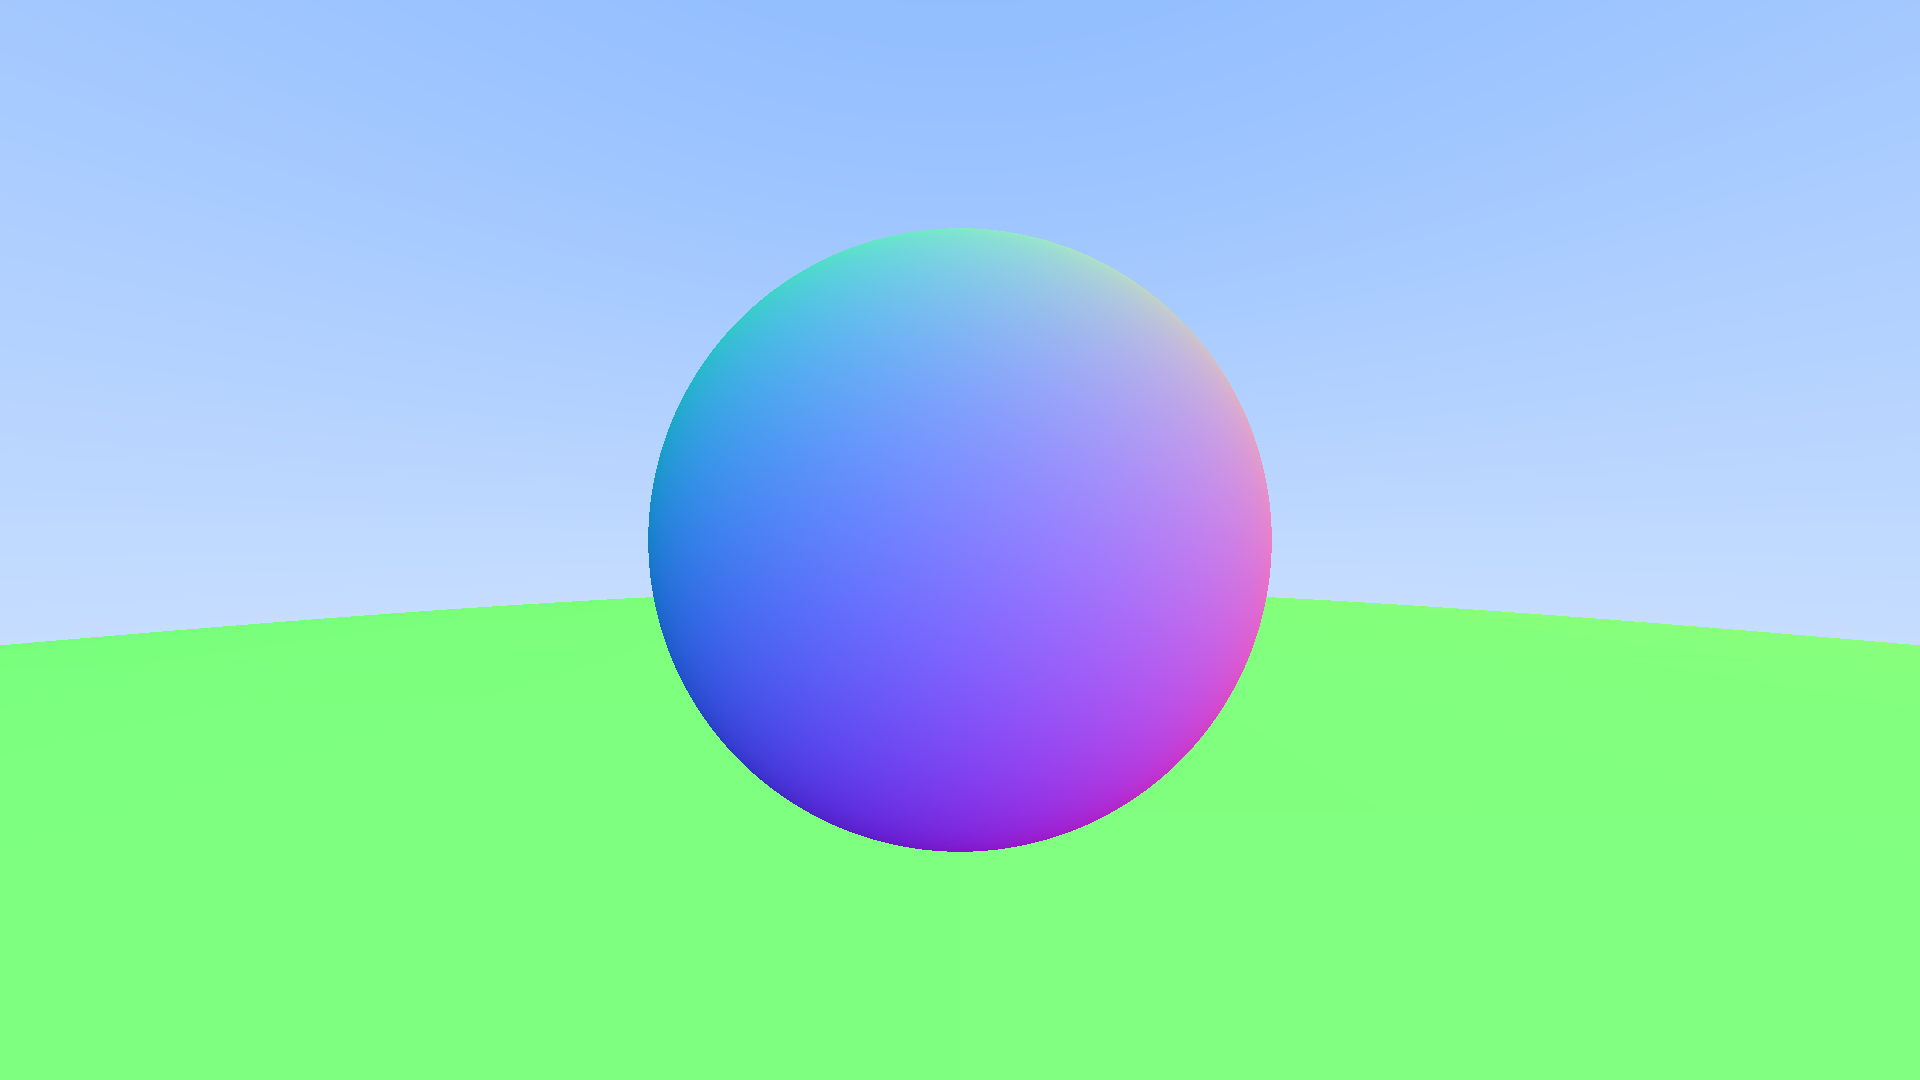

In [9]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")
from util.image_viewer import image_viewer
from util.scale_image import scale

a = image_viewer("output.ppm")
a

# Code Reduce

In [10]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

from util.ray import Ray
from util.vec3 import Vec3
from util.color import write_color
from util.vec3 import unit_vector
from util.vec3 import dot
from tqdm import tqdm
from util.hit_record import HitRecord
from util.hittable import Hittable
from util.sphere import Sphere
from util.hittable_list import HittableList
from util.interval import Interval

import math

In [11]:

# Constants
INFINITY = float("inf")
PI = math.pi

# Utility
def degrees_to_radians(deg):
    return deg * PI / 180.0

In [12]:
def ray_color(r, world):

    rec = HitRecord()

    # -----------------------------
    # HIT CHECK (WORLD INTERSECTION)
    # -----------------------------
    if world.hit(r,Interval(0.001, INFINITY), rec):

        # Convert normal (-1 to 1) → (0 to 1)
        return 0.5 * (rec.normal + Vec3(1, 1, 1))

    # -----------------------------
    # BACKGROUND GRADIENT
    # -----------------------------
    unit_dir = unit_vector(r.direction())

    t = 0.5 * (unit_dir.y + 1.0)

    white = Vec3(1, 1, 1)
    blue = Vec3(0.5, 0.7, 1.0)

    return white * (1 - t) + blue * t

In [13]:
def render():


    # -----------------------------
    # IMAGE CONFIGURATION
    # -----------------------------
    aspect_ratio = 16 / 9
    image_width = 1920
    image_height = int(image_width / aspect_ratio)

    # -----------------------------
    # SCENE SETUP
    # -----------------------------
    world = HittableList()

    world.add(Sphere(Vec3(0, 0, -1), 0.5))
    world.add(Sphere(Vec3(0, -100.5, -1), 100))

    # -----------------------------
    # CAMERA SETUP
    # -----------------------------
    viewport_height = 2.0
    viewport_width = viewport_height * (image_width / image_height)
    focal_length = 1.0

    camera_center = Vec3(0, 0, 0)

    viewport_u = Vec3(viewport_width, 0, 0)
    viewport_v = Vec3(0, -viewport_height, 0)

    pixel_delta_u = viewport_u / image_width
    pixel_delta_v = viewport_v / image_height

    viewport_upper_left = (
        camera_center
        - Vec3(0, 0, focal_length)
        - viewport_u / 2
        - viewport_v / 2
    )

    pixel00 = viewport_upper_left + 0.5 * (pixel_delta_u + pixel_delta_v)

    # -----------------------------
    # PPM HEADER (WRITE TO FILE)
    # -----------------------------
    with open("output.ppm", "w") as f:
        f.write(f"P3\n{image_width} {image_height}\n255\n")

        # -----------------------------
        # RENDER LOOP
        # -----------------------------
        for j in tqdm(range(image_height), desc="Rendering"):
            for i in range(image_width):

                pixel_center = (
                    pixel00
                    + pixel_delta_u * i
                    + pixel_delta_v * j
                )

                direction = pixel_center - camera_center
                r = Ray(camera_center, direction)

                # NOW uses HitRecord internally
                col = ray_color(r, world)

                ir = int(255.999 * col.x)
                ig = int(255.999 * col.y)
                ib = int(255.999 * col.z)

                f.write(f"{ir} {ig} {ib}\n")

    print("Done!")

render()




Rendering: 100%|██████████| 1080/1080 [00:25<00:00, 42.24it/s]

Done!


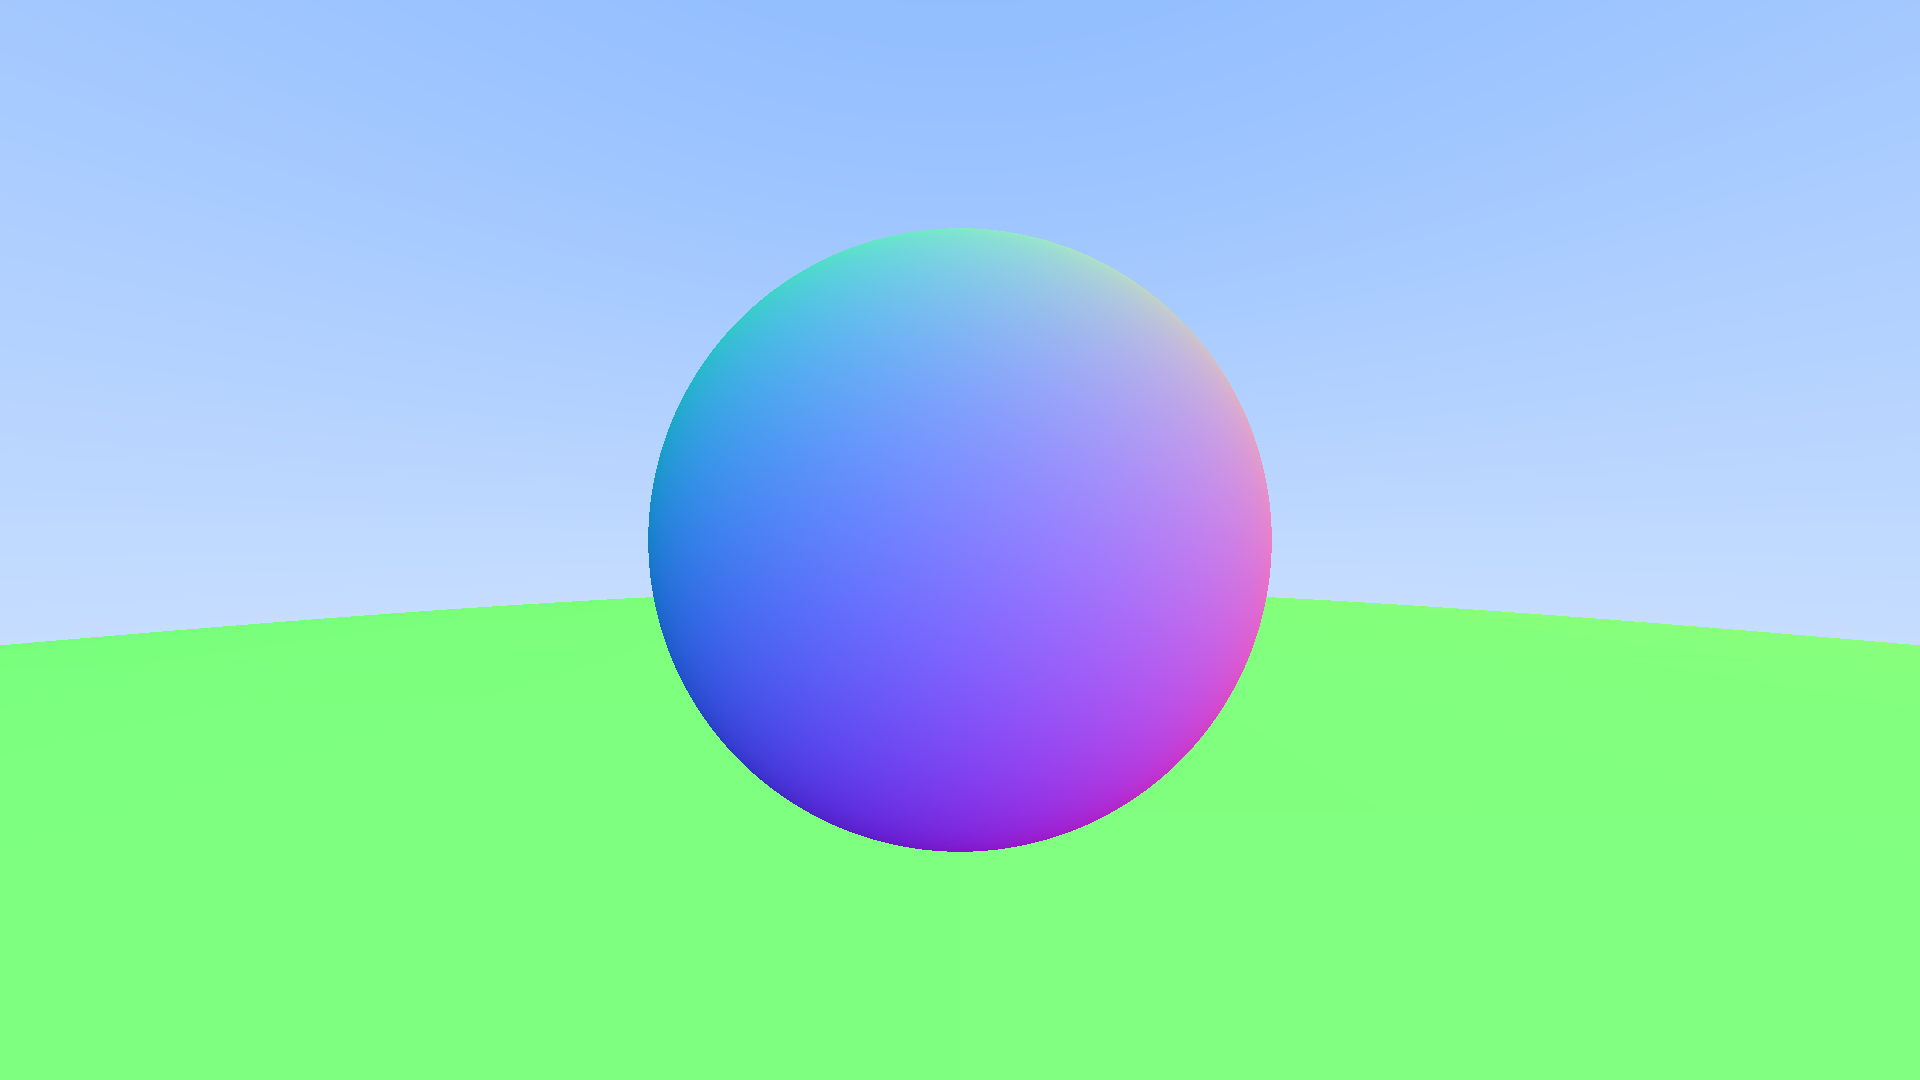

In [14]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")
from util.image_viewer import image_viewer
from util.scale_image import scale

a = image_viewer("output.ppm")
a